<a href="https://colab.research.google.com/github/rdsmaia/dim0494/blob/main/vae_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# hyperparameters
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 64
learning_rate = 0.001
num_epochs = 20
input_dim = 784
latent_dim  = 20
hidden_dim = 512
beta = 1.0

Dataset: note that we won't need a test dataset since we will ve generating samples from the trained model

In [5]:
# load MNIST
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform)
val_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform)

In [6]:
# dataloaders
train_loader = DataLoader(train_dataset,
                          batch_size=batch_size,
                          shuffle=True)
val_loader = DataLoader(val_dataset,
                        batch_size=batch_size,
                        shuffle=False)

Model definition: ConditionalVAE

In [7]:
class ConditionalVAE(nn.Module):
  '''
  Conditional Variational Autoencoder
  '''
  def __init__(self, input_dim, hidden_dim, latent_dim, num_classes=10):
        super().__init__()
        self.latent_dim = latent_dim
        self.num_classes = num_classes

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim + num_classes, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.ReLU(),
        )
        self.mu = nn.Linear(hidden_dim//2, latent_dim)
        self.log_var = nn.Linear(hidden_dim//2, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + num_classes, hidden_dim//2),
            nn.ReLU(),
            nn.Linear(hidden_dim//2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid(),
        )

  def encode(self, x, c):
        x = torch.cat([x, c], dim=1)
        x = self.encoder(x)
        mu, log_var = self.mu(x), self.log_var(x)
        return mu, log_var

  def reparametrize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

  def decode(self, z, c):
        z = torch.cat([z, c], dim=1)
        x_hat = self.decoder(z)
        return x_hat

  def forward(self, x, c):
        mu, log_var = self.encode(x, c)
        z = self.reparametrize(mu, log_var)
        x_hat = self.decode(z, c)
        return x_hat, mu, log_var

Several functions

In [8]:
def vae_loss(x, x_hat, mu, log_var, beta=1.0):
    '''
    VAE loss function
    '''
    # reconstructon loss
    reconstruction_loss = F.binary_cross_entropy(x_hat, x, reduction='sum')
    # regularization loss
    kl_divergence = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())

    # total loss
    total_loss = reconstruction_loss + beta * kl_divergence

    return total_loss, reconstruction_loss, kl_divergence

def train(model, train_loader, optimizer, beta=1.0, device='cuda'):
  '''
  Train the model
  '''
  model.train()

  # initialize losses
  total_loss = 0
  reconstruction_loss = 0
  kl_divergence = 0

  # processes the batches
  for batch_idx, (x, y) in enumerate(train_loader):

      # get a batch of data
      x, y = x.to(device), y.to(device)

      # reshape image (L, W, 1) -> (L*W, 1)
      x = x.view(x.size(0), -1)

      # transform the target into one-hot encoding
      y = F.one_hot(y, num_classes=10).float()

      # gradient initialization
      optimizer.zero_grad()

      # forward pass
      x_hat, mu, log_var = model(x, y)

      # get costs
      loss, recon_loss, kl_div = vae_loss(x, x_hat, mu, log_var, beta)

      # backward pass
      loss.backward()

      # accumulate losses
      total_loss += loss.item()
      reconstruction_loss += recon_loss.item()
      kl_divergence += kl_div.item()

      # model update (weight update)
      optimizer.step()

  # show training progress
  avg_loss = total_loss / len(train_loader.dataset)
  avg_recon_loss = recon_loss / len(train_loader.dataset)
  avg_kl_div = kl_divergence / len(train_loader.dataset)

  return avg_loss, avg_recon_loss, avg_kl_div

def validate(model, val_loader, beta=1.0, device='cuda'):
  '''
  Test the model
  '''
  model.eval()

  # initialize losses
  total_loss = 0
  reconstruction_loss = 0
  kl_divergence = 0

  # processes the batches
  with torch.no_grad():
    for batch_idx, (x, y) in enumerate(val_loader):

      # get a batch of data
      x, y = x.to(device), y.to(device)

      # reshape image (L, W, 1) -> (L*W, 1)
      x = x.view(x.size(0), -1)

      # transform the target into one-hot encoding
      y = F.one_hot(y, num_classes=10).float()

      # forward pass
      x_hat, mu, log_var = model(x, y)

      # get costs
      loss, recon_loss, kl_div = vae_loss(x, x_hat, mu, log_var, beta)

      # accumulate losses
      total_loss += loss.item()
      reconstruction_loss += recon_loss.item()
      kl_divergence += kl_div.item()

  # show training progress
  avg_loss = total_loss / len(val_loader.dataset)
  avg_recon_loss = recon_loss / len(val_loader.dataset)
  avg_kl_div = kl_divergence / len(val_loader.dataset)

  return avg_loss, avg_recon_loss, avg_kl_div

def generate_conditional_samples(model, class_labels, num_samples_per_class=5):
  '''
  Generate conditional samples from the model
  '''
  model.eval()

  # Grid de visualização
  num_classes = len(class_labels)
  fig, axes = plt.subplots(num_classes, num_samples_per_class, figsize=(12, 10))

  with torch.no_grad():
    for i, label in enumerate(class_labels):

        # Cria one-hot encoding da classe
        c = F.one_hot(torch.tensor([label] * num_samples_per_class), model.num_classes).float().to(device)

        # Amostra pontos latentes do prior
        z = torch.randn(num_samples_per_class, model.latent_dim).to(device)

        # Decodifica com condicionamento na classe
        samples = model.decode(z, c)
        samples = samples.view(-1, 1, 28, 28)

        # Mostra as amostras
        for j in range(num_samples_per_class):
          axes[i, j].imshow(samples[j].cpu().squeeze().numpy(), cmap='gray')
          axes[i, j].axis('off')

          if j == 0:
            axes[i, j].set_title(f'Classe {label}')

  plt.tight_layout()
  plt.show()


Train model

In [9]:
# load the model
model = ConditionalVAE(input_dim, hidden_dim, latent_dim).to(device)

# set optimizer
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [10]:
# main training loop
loss_all = []
recon_loss_all = []
kl_div_all = []
val_loss_all = []
val_recon_loss_all = []
val_kl_div_all = []

for epoch in range(1, num_epochs + 1):

  # training
  loss, recon_loss, kl_div = train(model, train_loader, optimizer, beta, device)

  # validation
  val_loss, val_recon_loss, val_kl_div = validate(model, val_loader, beta, device)

  # show training progress
  print(f'Epoch: {epoch}, Loss: {loss:.4f}, Recon Loss: {recon_loss:.4f}, KL Div: {kl_div:.4f}, val Loss: {val_loss:.4f}, recon val loss: {val_recon_loss:.4f}, val KL div: {val_kl_div:.4f}')

  # accumulate losses
  loss_all.append(loss)
  recon_loss_all.append(recon_loss)
  kl_div_all.append(kl_div)
  val_loss_all.append(val_loss)
  val_recon_loss_all.append(val_recon_loss)
  val_kl_div_all.append(val_kl_div)

Epoch: 1, Loss: 148.3268, Recon Loss: 0.0560, KL Div: 10.2192, val Loss: 118.7336, recon val loss: 0.1558, val KL div: 13.6960
Epoch: 2, Loss: 114.7298, Recon Loss: 0.0482, KL Div: 14.4176, val Loss: 109.9347, recon val loss: 0.1339, val KL div: 15.1186
Epoch: 3, Loss: 108.1792, Recon Loss: 0.0442, KL Div: 15.5259, val Loss: 105.6519, recon val loss: 0.1267, val KL div: 15.6892
Epoch: 4, Loss: 104.6372, Recon Loss: 0.0468, KL Div: 16.0449, val Loss: 102.9205, recon val loss: 0.1233, val KL div: 16.2311
Epoch: 5, Loss: 102.5409, Recon Loss: 0.0458, KL Div: 16.3000, val Loss: 101.3308, recon val loss: 0.1238, val KL div: 16.2381
Epoch: 6, Loss: 101.1120, Recon Loss: 0.0435, KL Div: 16.4308, val Loss: 100.5144, recon val loss: 0.1250, val KL div: 16.5024
Epoch: 7, Loss: 100.0031, Recon Loss: 0.0458, KL Div: 16.5397, val Loss: 99.6985, recon val loss: 0.1232, val KL div: 16.6559
Epoch: 8, Loss: 99.1845, Recon Loss: 0.0467, KL Div: 16.6132, val Loss: 99.3476, recon val loss: 0.1210, val KL 

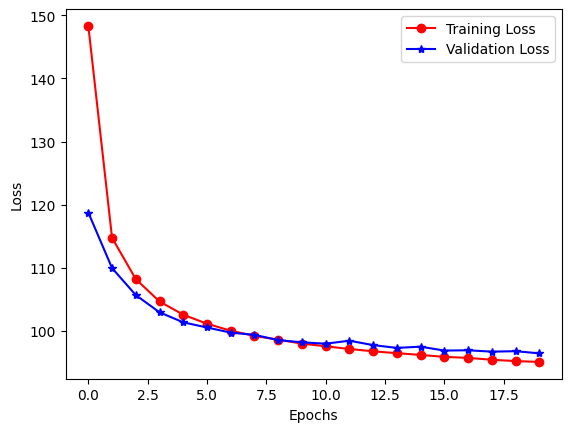

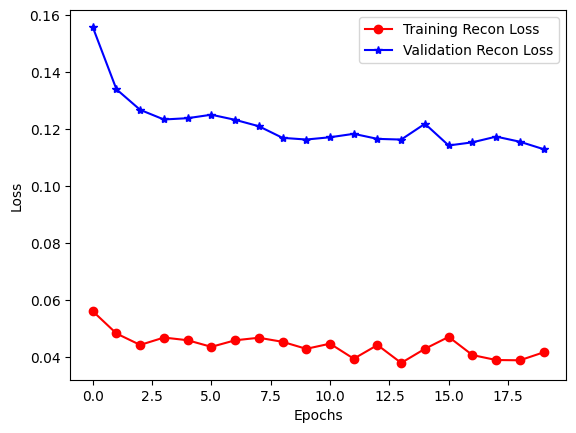

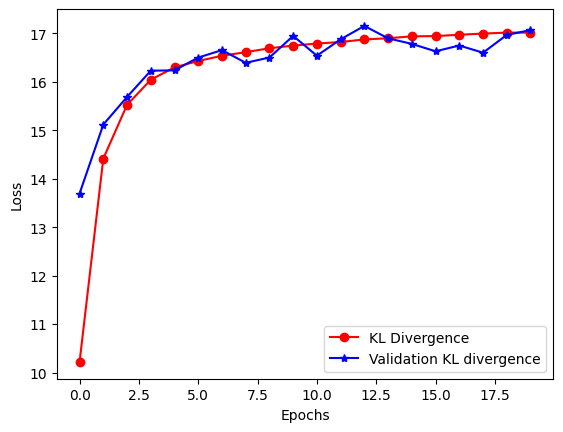

In [14]:
recon_loss_all = [r.item() for r in recon_loss_all]
val_recon_loss_all = [r.item() for r in val_recon_loss_all]

# observe the learning curves
plt.plot(loss_all, 'r-o', label='Training Loss')
plt.plot(val_loss_all, 'b-*', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# observe the learning curves
plt.plot(recon_loss_all, 'r-o', label='Training Recon Loss')
plt.plot(val_recon_loss_all, 'b-*', label='Validation Recon Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# observe the learning curves
plt.plot(kl_div_all, 'r-o', label='KL Divergence')
plt.plot(val_kl_div_all, 'b-*', label='Validation KL divergence')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Test model

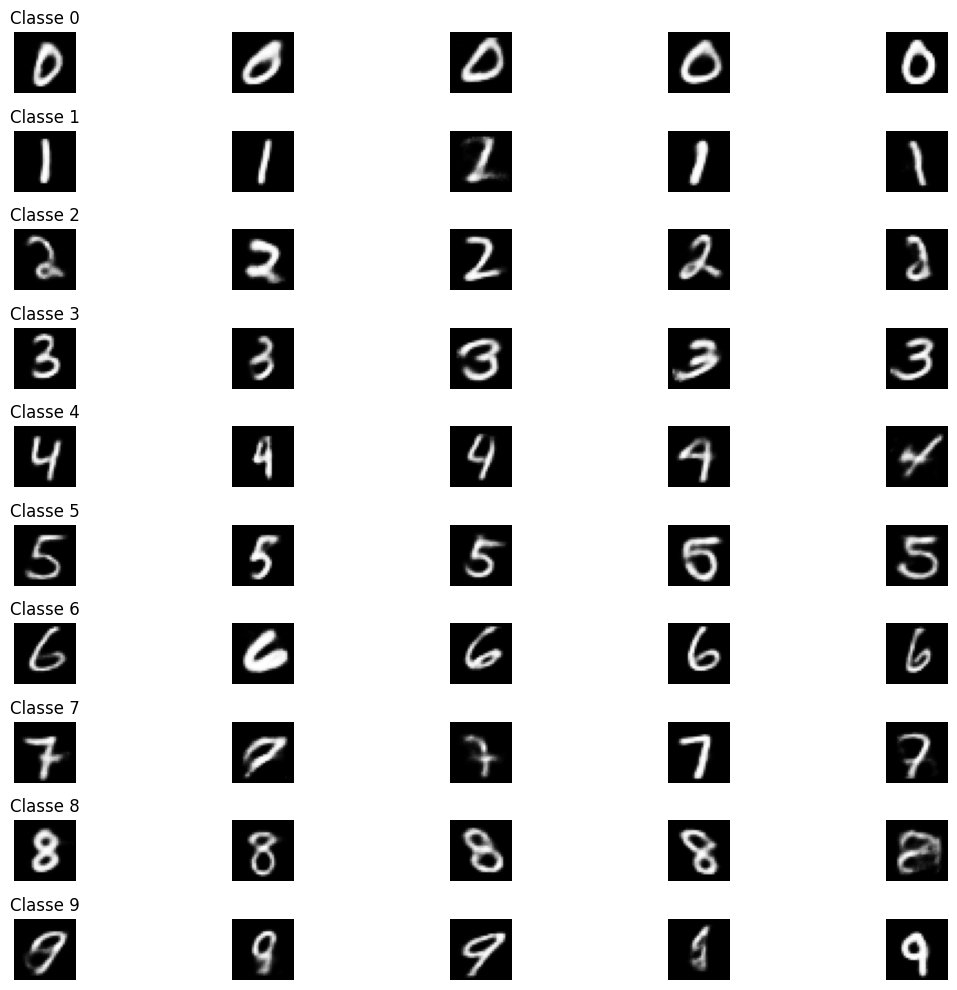

In [15]:
generate_conditional_samples(model, class_labels=range(10))